# Sentiment Analysis: Deep Dive into Twitter Data

## Notebook 5: LSTM Neural Network and Performace Evaluation

In Notebook 5, the model architecture advances to Long Short-Term Memory (LSTM) networks. These are specialized to remember information for extended periods and are particularly well-suited for sequence data like text. The experiment aims to explore whether the added complexity of LSTM layers improves the model's performance in sentiment analysis compared to the basic neural network.

## Importing Libraries and Dependencies

In [2]:
# Importing libraires for file and time operations
import os
import time
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module="mlflow")


# Library for random number generation and iteration
import random
from itertools import product
from tqdm import tnrange,tqdm


# Basic libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline


# machine learning libraries using Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc


# library for Word2Vec model
import gensim
from gensim.models import Word2Vec


# NLTK libraries
import nltk
from nltk import tokenize
from nltk.tokenize import WhitespaceTokenizer


# Libraries for Deep Learning with PyTorch
import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn, optim
import torch.nn as nn
import torch.nn.functional as F


# Library for clearing Jupyter Notebook cell output
from IPython.display import clear_output


# library for experiment tracking using MLFlow
import mlflow
import mlflow.pytorch

ModuleNotFoundError: No module named 'mlflow'

## Load Dataset

In the previous notebook (Notebook 1), we performed text pre-processing and cleaned the Twitter dataset. Now, we will import the saved pre-processed dataset into memory for further use.

The current dataset consists of 1.6 million tweets, which is quite large for training an Artificial Neural Network (ANN) model efficiently. To simplify the process and reduce training time, we will randomly select a subset of 100,000 tweets from the complete pre-processed dataset.

This smaller subset will allow us to train and evaluate the ANN model more quickly while still maintaining a representative sample of the data for sentiment analysis.

In [14]:
# load the dataset into memory
dataset_1 = pd.read_csv("training_processed_data_final_notebook1.csv")
dataset = dataset_1.sample(100000)
dataset.sample(5)

,target,text
1059121,1,try work thing
667789,0,people follow mei feel lonely follower u j
304344,0,hope soo mact news sad day
1092523,1,hyper dayy hope energy tomorrow
1373662,1,not do mile hair listen matt giraud twitteringg


In [15]:
dataset['target'].value_counts()

,count
target,
1,50197
0,49803


In [16]:
# removing the null values
dataset.dropna(axis = 0, how = 'any', inplace = True)
dataset.isnull().sum()

,0
target,0
text,0


In [17]:
dataset.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 99998 entries, 476143 to 425102
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   target  99998 non-null  int64 
 1   text    99998 non-null  object
dtypes: int64(1), object(1)
memory usage: 10.3 MB


## Setting the seed for reproducibility

Setting seeds is a crucial step in ensuring reproducibility in deep learning experiments. By fixing the random seed for libraries like `NumPy`, `PyTorch`, and `Python`'s built-in random module, we can control the randomness in weight initialization, data shuffling, and other stochastic processes. This ensures that the results remain consistent across multiple runs, allowing for fair comparisons and reliable experimentation.

In [18]:
def set_seed(seed_value):
    # python random seed
    random.seed(seed_value)
    
    # numpy random seed
    np.random.seed(seed_value)

    os.environ['PYTHONHASHSEED'] = str(seed_value)

    # Pytorch CPU seed
    torch.manual_seed(seed_value)

    # CuDNN deterministic mode
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # generator for torch
    generator = torch.Generator().manual_seed(seed_value)
    
    # PyTorch's GPU seed (if available)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        
set_seed(42)

## Setting up the computational Device

In deep learning, especially when working with large datasets, using a GPU can significantly speed up the training process. Before training the neural network, we check if a GPU is available.

If a GPU is detected, it is set as the default device; otherwise, the system defaults to the CPU. The selected device is then used for all subsequent computations and model training. By displaying the chosen device, we can confirm the computational resource being utilized.

In [19]:
# Select GPU if available, otherwise use CPU
if torch.cuda.is_available():
    # GPU selection
    device = torch.device("cuda")
    print(f'There are {torch.cuda.device_count()} GPUs available.')
    print(f"Device select for training : {torch.cuda.get_device_name(0)}")
else:
    # CPU Selection
    device = torch.device("cpu")
    print("No GPU available, using the CPU instead.")

No GPU available, using the CPU instead.


## Word Count Analysis in Tweets

In this section, the distribution of word counts in tweets is analyzed to determine an optimal value for `max_len_tweet`, balancing the retention of relevant information with memory efficiency.

Descriptive statistics, including the 90th and 95th percentiles, are calculated and visualized through a histogram and a boxplot, facilitating the identification of a threshold that minimizes memory wastage without losing crucial information.

In [20]:
# initialize WhitespaceTokenizer()
tokenizer = WhitespaceTokenizer()

# test example and working of get_tokenizer
print(tokenizer.tokenize('Hello!, this is a tokenizer that we are testing'))

['Hello!,', 'this', 'is', 'a', 'tokenizer', 'that', 'we', 'are', 'testing']


,count,mean,std,min,25%,50%,75%,90%,95%,98.5%,max
text,99998.0,6.190514,3.48668,1.0,3.0,6.0,8.0,11.0,13.0,15.0,34.0


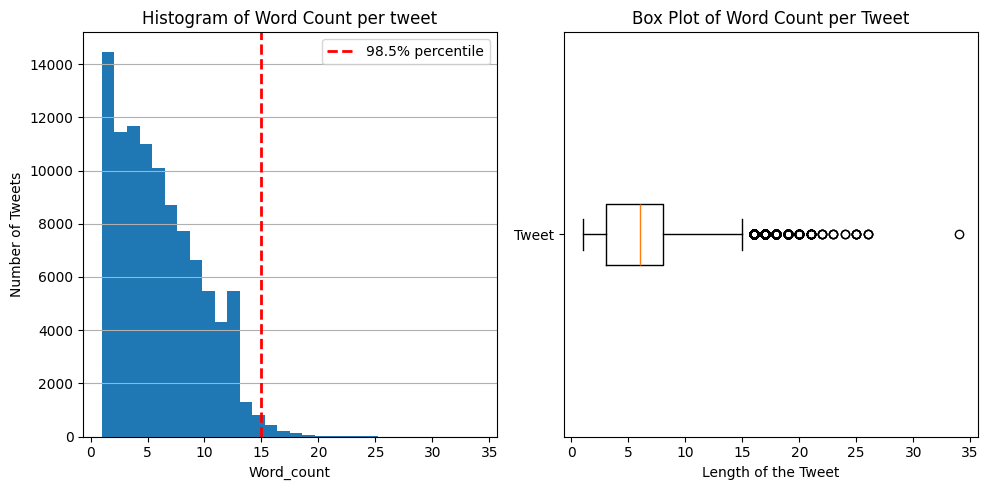

In [21]:
# calculate the lenght of each tweet in dataset and store in len_tweet
len_tweet = dataset['text'].map(tokenizer.tokenize).map(len)

# check descriptive statistic for length of the tweets
describe = pd.DataFrame(len_tweet.describe()).T
## calculating 90%, 95% and 98.5% percentile length of the tweets
percentile_90 = len_tweet.quantile(0.90)
percentile_95 = len_tweet.quantile(0.95)
percentile_985 = len_tweet.quantile(0.985)
# appending 90,95 and 98.5 percentile values to descirbe
describe['90%'] = percentile_90
describe['95%'] = percentile_95
describe['98.5%'] = percentile_985

# rearranging the columns orders
describe = describe[[col for col in describe.columns if col != 'max']+['max']]
display(describe)

# histogram of word count per tweets
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
plt.hist(len_tweet,bins = 30)
plt.title("Histogram of Word Count per tweet")
plt.axvline(percentile_985, color = 'red', linestyle = 'dashed', linewidth = 2,
            label = '98.5% percentile')
plt.xlabel("Word_count")
plt.ylabel("Number of Tweets")
plt.legend()
plt.grid(axis = 'y')

# Boxplot of word count per tweet
plt.subplot(1,2,2)
plt.boxplot(list(len_tweet), vert = False)
plt.title("Box Plot of Word Count per Tweet")
plt.xlabel("Length of the Tweet")
plt.yticks([1],["Tweet"])

# Adjust the layout
plt.tight_layout()
plt.show()

We can see that 98.5% of the tweets have a length of 15 words, hence the max length of the words that we will be using to train the LSTM on will be 15 words.
If the length of tweets are larger than 15 words then we will truncate it or otherwise for shorted tweets we will add padding tokens to it.  

In [22]:
# Define the maximum length for tweet
MAX_LEN_TWEET = 15

# Define a unknown token
unk_token = '<unk>'

# Define a pad token
pad_token = "<pad>"

### Function for Padding the truncating the tweets

As per our above analysis, we will truncate the lenght of the tweets to `MAX_LEN_TWEET` length or pad the tweets with `pad_tokens` which are smaller than the `MAX_LEN_TWEET` length

In [23]:
# function for padding and truncating tweets
def pad_tokens(tokens):
    if len(tokens)>=MAX_LEN_TWEET:
        return tokens[:MAX_LEN_TWEET]
    else:
        return tokens + [pad_token]*(MAX_LEN_TWEET-len(tokens))

## Load Models CBOW_Word2Vec

We will use the pre-trained Word2Vec model from Notebook 2 to convert the tweet text into numerical vectors. For now, we will only utilize the CBOW Word2Vec model that we previously trained.

In [24]:
# path to pre-trained Word2Vec models (CBOW, Skipgram)
cbow_path = "/content/CBOW_Word2Vec.model"

# Load CBOW_Word2Vec model
cbow = Word2Vec.load(cbow_path)

We need to add `<pad_token>` and `<unk_token>` to the vocabulary of the `CBOW_Word2Vec` model to enable vectorization of unknown words and padding tokens in tweets processed through the `pad_tokens` function."

In [25]:
# Adding unk and pad tokens to cbow word2vec model

# Manually set the index of <unk> and <pad> to 0 and 1
cbow.wv.key_to_index = {**{'<unk>': 0, '<pad>': 1}, **cbow.wv.key_to_index}

# Update index_to_key to manually assign <unk> and <pad> at the correct positions
cbow.wv.index_to_key = ['<unk>', '<pad>'] + cbow.wv.index_to_key

In [27]:
# create cbow vocabulory for CBOW Word2Vec model
vocab_cbow = list(cbow.wv.index_to_key)
cbow_word_to_idx = {word:idx for idx, word in enumerate(vocab_cbow)}

Experiment to check proper functioning of padding and vectorization of `<pad_tokens>` and `<unk_tokens>`

## Custom Pytorch Dataset

In this project, we use `PyTorch Dataset` class to efficiently manage and preprocess our data. It enables us to load and vectorize tweet text on-the-fly during training, ensuring seamless integration with `Word2Vec` embeddings. This approach not only saves memory but also simplifies feeding data into our neural network, making the pipeline more efficient and scalable.

For tokenizing the text, we will use the `WhitespaceTokenizer` from the `NLTK` library.

In [30]:
# make a custom pytorch dataset
class TwitterDataset(Dataset):
    
    def __init__(self, df,word2vec_model, is_test = False):
        self.df = df
        self.is_test = is_test
        self.word2vec_model = word2vec_model
        self.embedding_dim = word2vec_model.vector_size
    
    def __getitem__(self, index):
        tweet_text = self.df['text'].values[index]
        
        # pad tokens
        tweet_tokens = pad_tokens(tokenizer.tokenize(tweet_text))

        # vectorizing the text
        word_vectors = [self.word2vec_model.wv[word] if word in self.word2vec_model.wv else np.zeros(self.embedding_dim) for word in tweet_tokens]
        
        # final input to handle null word_vectors
        if len(word_vectors) == 0:
            word_vectors = [np.zeros(self.embedding_dim)] * MAX_LEN_TWEET

        word_vectors = torch.tensor(word_vectors, dtype=torch.float32)
        
        # target
        target = torch.tensor([self.df['target'].values[index]], dtype = torch.float32)

        return word_vectors, target

    def __len__(self):
        return len(self.df)

Using PyTorch Dataset class, we created a custom `TwitterDataset` class to vectorize each tweet and its corresponding target label in the dataset.

To handle cases where tokenized words from a tweet (using `WhitespaceTokenizer`) are not found in the `CBOW_Word2Vec` model's vocabulary, the class returns a null tensor with the same dimensions as the vocabulary (here, `200`).

## Splitting the dataset into train and test data

We will be splitting the data into 3 different dataset, namely `Training_dataset`, `val_dataset` and `testing_dataset`.

First, we will be dividing the dataset into two groups training and testing data, further more we will divide the training data into two groups actuall training data and validation data. Validation data will be used for hyperparameter tuning of the models.

In [33]:
# Length of the split
TRAIN_SIZE = int(0.7*len(dataset))
VAL_SIZE = int(0.2*len(dataset))
TEST_SIZE = len(dataset)-TRAIN_SIZE-VAL_SIZE

print(TRAIN_SIZE,VAL_SIZE,TEST_SIZE)

69998 19999 10001


In [38]:
# Step 1: Split into train and temp (val + test)
train_dataset_split, temp_df = train_test_split(dataset, test_size=(VAL_SIZE + TEST_SIZE), random_state=42, shuffle=True)

# Step 2: Split temp into validation and test
val_dataset_split, test_dataset_split = train_test_split(temp_df, test_size=(TEST_SIZE / (VAL_SIZE + TEST_SIZE)), random_state=42, shuffle=True)

print(len(train_dataset_split), len(val_dataset_split),len(test_dataset_split))

69998 19999 10001


In [39]:
# Pytorch Dataset instances
train_dataset = TwitterDataset(train_dataset_split, word2vec_model = cbow)
val_dataset = TwitterDataset(val_dataset_split, word2vec_model = cbow)
test_dataset = TwitterDataset(test_dataset_split, word2vec_model = cbow)

In [40]:
# Experiment
temp_1 = dataset[:10]
temp = TwitterDataset(temp_1, word2vec_model = cbow, is_test = False)
print(temp[0][0].shape)
print(temp[0][1].shape)

torch.Size([15, 200])
torch.Size([1])


## Pytorch Dataloaders

We will use a `BATCH_SIZE` of 64 to ensure the system can efficiently load and vectorize the data for the next batch during training.

In [43]:
# BATCH_SIZE
BATCH_SIZE = 64

# Pytorch Dataloader
train_loader = DataLoader(train_dataset, batch_size  = BATCH_SIZE, num_workers = 2, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size  = BATCH_SIZE*3, num_workers = 2, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size  = BATCH_SIZE*3, num_workers = 2, persistent_workers=True )

In [44]:
# Experiment
for inputs, targets in train_loader:
  print(f"size of input {inputs.shape} and target is {targets.shape}")
  break

for inputs, targets in val_loader:
  print(f"size of input {inputs.shape} and target is {targets.shape}")
  break

for inputs, targets in test_loader:
  print(f"size of input {inputs.shape} and target is {targets.shape}")
  break

size of input torch.Size([64, 15, 200]) and target is torch.Size([64, 1])
size of input torch.Size([192, 15, 200]) and target is torch.Size([192, 1])
size of input torch.Size([192, 15, 200]) and target is torch.Size([192, 1])


## Build LSTM Neural Network

In this section, we build and train an `LSTM (Long Short-Term Memory)` neural network for sentiment analysis. LSTMs are a type of `RNN` designed to capture long-term dependencies in sequential data using memory cells and gating mechanisms. 

We define the `LSTM_Classifier` using `PyTorch`, incorporating an embedding layer, LSTM layers, and fully connected layers for classification. The model processes numerical tweet representations from `Word2Vec`, leveraging contextual relationships in text. By learning sequential patterns, the LSTM improves sentiment classification performance compared to traditional models.

In [46]:
# LSTM Neural Network
class LSTM_classifier(nn.Module):
    
    # LSTM Model struture
    def __init__(self, input_size, hidden_size, output_size, n_layers, dropout_prob = 0.2):
        super(LSTM_classifier,self).__init__()

        self.hidden_size = hidden_size
        self.n_layers = n_layers

        self.lstm = nn.LSTM(input_size = input_size,
                            hidden_size = hidden_size,
                            num_layers = n_layers,
                            batch_first = True,
                            dropout = dropout_prob if n_layers>1 else 0)

        self.batch_norm = nn.BatchNorm1d(hidden_size)
        self.linear = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_prob)
        # self.relu = nn.ReLU()
    
    # Forward Propagation
    def forward(self,x):

        lstm_out, (_, _) = self.lstm(x)
        lstm_out = self.dropout(lstm_out[:,-1,:])
        lstm_out = self.batch_norm(lstm_out)
        output = self.linear(lstm_out)

        return output

Training loop for a single epoch: The `DataLoader` efficiently splits the `training_dataset` into batches, which are then vectorized using the `TwitterDataset` class. These vectorized batches serve as input to the `LSTM` model Classifier built earlier, enabling efficient training and optimization.

In [47]:
# Training function for a single epoch
def train(train_loader, net,epoch, criterion,optimizer):
    
    # model in training phase
    net.train()
    epoch_loss = []
    
    for batch_idx, batch in enumerate(tqdm(train_loader)):
        # separate data and target
        inputs, target = batch
        
        # mode the data and target to the chosen device
        inputs , target = inputs.to(device), target.to(device)
        
        # Forward propagation and compute predictions and loss
        pred = net(inputs)
        loss = criterion(pred, target)
        epoch_loss.append(loss.item())
        
        # Backward propagation and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Convert epoch loss to numpy array and compute mean
    epoch_loss = np.array(epoch_loss)
    epoch_loss_avg = epoch_loss.mean()

    print(f"Epoch {epoch}: Average train Loss: {epoch_loss_avg:.4f}")

    return epoch_loss_avg

In [49]:
# validaiton loop for model performance evaluation
def test(test_loader, net, epoch, criterion):
    
    # network for evaluation mode
    net.eval()

    # Disable gradient calculation for performance calculation
    with torch.no_grad():
        
        # Initiate loss list to store the loss
        epoch_val_loss = []
        
        # Iterate through each batch in the test data loader
        for batch_idx, batch in enumerate(tqdm(val_loader)):
            
            data,target = batch

            # Move data and target to the chosen device
            data, target = data.to(device), target.to(device)

            # Forward pass: compute predictoins and loss
            pred = net(data)
            loss = criterion(pred, target)
            epoch_val_loss.append(loss.item())

        #Convcer the epoch loss to numpy array and compute the mean
        epoch_val_loss = np.asarray(epoch_val_loss)
        epoch_val_loss_avg = epoch_val_loss.mean()

        print(f"Epoch {epoch}: Average test Loss: {epoch_val_loss_avg:.4f}")

    return epoch_val_loss_avg

Below is the main training function for training the `LSTM_classifier` model over 500 epochs. The model architecture consists of an input layer with `input_size = 200` (vector dimensions), a hidden layer with `hidden_size_1 = 32`.

We utilize `MLflow` to track input parameters and different hyperparameter configurations from the param_grid defined below. This allows us to store the best model for each hyperparameter setting and compare them efficiently.

The model is trained using `BCEWithLogitsLoss` as the loss function and `AdamW` as the optimizer to ensure effective learning.

After training the `LSTM_classifier` model across different hyperparameter settings, we load the best-performing model for each configuration and evaluate its performance on the test dataset using test_dataloader.

In [50]:
# Main training loop for LSTM
def train_LSTM(args, hidden_size = 32, input_size = 200, output_size = 1):
    
    # Start MLflow run for experiment tracking
    with mlflow.start_run(experiment_id = experiment_id):
        # Log hyperparameters
        for key, value in args.items():
            mlflow.log_param(key, value)
            
        # Log neural network architecture details
        mlflow.log_param('input_size', input_size)
        mlflow.log_param('hidden_size',hidden_size)
        mlflow.log_param('output_size', output_size)
        
        # initiating the Classifer ANN Model
        net = LSTM_classifier(input_size = input_size, hidden_size = hidden_size,
                              output_size = output_size, n_layers = 2)
        
        net.to(device)
        
        # learning rate and weight decay from para_grid
        lr = args['lr']
        weight_decay = args['weight_decay']
        
        # loss function
        criterion = nn.BCEWithLogitsLoss().to(device)
        
        # Adam optimizer
        optimizer = optim.AdamW(net.parameters(), lr = lr, weight_decay = weight_decay)
        
        # initializes variable to keep track of losses and other metrics
        train_losses, test_losses = [],[]
        best_test_loss = float('inf')
        best_model_epoch = 1
        no_improvement_epochs = 0
        epoch_durations = []

        # start time of model training
        start_time = time.time()

        # Main training loop
        num_epochs = args['num_epochs']
        for epoch in range(num_epochs):
            epoch_start_time = time.time()
            print(f"Training LSTM Neraul Network ...... Epoch {epoch} of {num_epochs}")
            
            # calculating model training duration and best model epoch
            if len(epoch_durations)>0:
                mean_time = np.mean(epoch_durations)
                estimative = ((num_epochs-epoch)*mean_time)
                print(f'Mean Epoch Time duaration {mean_time} seconds | Esitmated time to finish training {estimative} seconds')

            if best_model_epoch !=1:
                print(f"Best test loss epoch {best_model_epoch}")
                
            # Training the network and logging the loss
            epoch_train_loss = train(train_loader,net, epoch, criterion, optimizer)
            train_losses.append(epoch_train_loss)
            mlflow.log_metric('epoch_train_loss', epoch_train_loss, step = epoch)

            # Validating the neural network and logging the loss
            epoch_test_loss = test(val_loader, net, epoch, criterion)
            test_losses.append(epoch_test_loss)
            mlflow.log_metric("epoch_test_loss", epoch_test_loss, step=epoch)

            diff = best_test_loss - epoch_test_loss

            # Checks for improvements in test loss
            if epoch_test_loss< best_test_loss:
                best_test_loss = epoch_test_loss

                # Save the state of the best model for future reference
                torch.save(net.state_dict(),"backup_best_model.pth")
                mlflow.log_metric("best_test_loss_so_far", best_test_loss, step=epoch)
                best_model_epoch = epoch

            # early stopping based on a predefined tolerance and patience
            if diff> args['tolerance']:
                no_improvement_epoch = 0
            else:
                no_improvement_epoch +=1
            
            if no_improvement_epoch > args['patience']:
                print(f"Early stopping at epoch: {epoch} ")
                break
            
            # Records the time at each epoch and calculates the duration 
            epoch_end_time = time.time()
            epoch_durations.append(epoch_end_time - epoch_start_time)

        # Records the time at which training ends and calculates the duration
        end_time = time.time()
        duration = end_time - start_time

        print(f"LSTM Neural network training has finished. Elapsed time {duration} ")
        print("Best model saved")
        print(f"Best test loss epoch {best_model_epoch}")
        
        # Loads the best model
        true_test_labels, predicted_test_labels = [], []
        net.load_state_dict(torch.load("backup_best_model.pth"))

        # Uses the best model to make predictions on the test data
        with torch.no_grad():
            for batch in test_loader:
                inputs, target = batch
                inputs, target = inputs.to(device), target.to(device)
                pred = net(inputs)
                true_test_labels.extend(inputs.detach().cpu().numpy())
                predicted_test_labels.extend((torch.sigmoid(pred).squeeze() > 0.5).detach().cpu().numpy())

            # Calculates performance metrics and logs them using MLflow
            test_accuracy = accuracy_score(true_test_labels, predicted_test_labels)
            test_precision = precision_score(true_test_labels, predicted_test_labels)
            test_recall = recall_score(true_test_labels, predicted_test_labels)
            test_f1 = f1_score(true_test_labels, predicted_test_labels)
            
            # Logging the output and performance results to Mlflow
            mlflow.pytorch.log_model(net, "models")
            mlflow.log_metric("test_accuracy", test_accuracy)
            mlflow.log_metric("test_precision", test_precision)
            mlflow.log_metric("test_recall", test_recall)
            mlflow.log_metric("test_f1", test_f1)
            mlflow.log_metric("duration", duration)

            # Prints the performance metrics of the best model
            print("Best model metrics:")
            print('Accuracy: {:.4f}, Precision: {:.4f}, Recall: {:.4f}, F1: {:.4f}'.format(test_accuracy, test_precision, test_recall, test_f1))

    return(train_losses, test_losses, best_model_epoch)

## Tracking Model Experiments with MLflow

This section initializes experiment tracking using MLflow. The code ensures that an experiment named `LSTM` is properly set up. If the experiment already exists, its ID is retrieved; otherwise, a new one is created. This setup enables systematic tracking of different model runs, along with their corresponding metrics, parameters, and outcomes.

In [51]:
# Set the experiment name for MLflow tracking
experiment_name = 'LSTM'

# Check if experiment exists, create if not
if mlflow.get_experiment_by_name(experiment_name) is None:
    experiment_id =mlflow.create_experiment(experiment_name)
else:
    # get the exisiting experiment ID
    experiment_id = mlflow.get_experiment_by_name(experiment_name).experiment_id

## Hyperparameter Grid Setup and Model Training

This section implements a grid search approach to identify the optimal hyperparameter combination for the neural network. By systematically exploring different configurations—including `learning rate(lr), weight decay(weight_decay)`, and `tolerance` method—the model undergoes an exhaustive search across the specified hyperparameter grid. Each configuration's performance is logged, enabling the selection of the most effective setup for achieving optimal model performance.

In [52]:
# Define the parameter grid for hyperparameter tuning
param_grid = {
    'vectorization' : ['cbow'],
    'criterion' : ['BCEWithLogitsLoss'],
    'optimizer' : ['Adam'],
    'batch_size' : [128],
    'num_workers' : [0],
    "lr" : [0.0001,0.0005, 0.001], #,
    'weight_decay' : [0.0001,0.0005, 0.001], #,0.0005, 0.001
    'num_epochs' : [500],
    'tolerance' : [0.0003],
    'patience' : [5]
}

# Generate all combinattions of hyperparameters for grid search
all_combinations = [dict(zip(param_grid,v)) for v in product(*param_grid.values())]

In [54]:
# Function to remove already trained combinations from the list
def remove_trained(combinations, experiment_id):
    # Fetch all runs from MLflow for the given experiment ID
    runs = pd.DataFrame(mlflow.search_runs(experiment_id))

    trained_lst = []
    not_trained_lst = []

    # Loop through all runs to gather parameters of trained models
    for i in range(runs.shape[0]):
        run = runs.iloc[i]
        params = {
            'vectorization': run['params.vectorization'],
            'criterion': run['params.criterion'],
            'optimizer': run['params.optimizer'],
            'batch_size': int(run['params.batch_size']),
            'num_workers': int(run['params.num_workers']),
            'lr': float(run['params.lr']),
            # 'weight_decay': float(run['params.weight_decay']),
            'num_epochs': int(run['params.num_epochs']),
            'tolerance': float(run['params.tolerance']),
            'patience': int(run['params.patience'])
        }

        trained_lst.append(params)

    # Check which combinations are not yet trained
    for i in range(len(combinations)):
        already_trained = False

        for j in range(len(trained_lst)):
            if combinations[i] == trained_lst[j]:
                already_trained = True

        if not already_trained:
            not_trained_lst.append(combinations[i])

    return(not_trained_lst)

# Remove already trained combinations from the list
not_trained_lst = remove_trained(all_combinations,experiment_id)

# Check if any combinations are left to train
if len(not_trained_lst)>0:
    print('There are {} combinations left to train.'.format(len(not_trained_lst)))
else:
    print('All models have already been trained.')

There are 9 combinations left to train.


In [55]:
# Initialize an empty list to store the results
results = []

# Record the start time for the training process
start_time = time.time()

# Loop through each combination of hyperparameters that have not yet been trained
for params in all_combinations:
  # Train the neural network with the given parameters
  train_losses, test_losses, best_epoch = train_LSTM(params, hidden_size=params.get('hidden_size', 32), input_size=params.get('input_size', 200), output_size=params.get('output_size', 1))


  # Append the training results to the results list
  results.append({
      'params': params,
      'train_losses': train_losses,
      'test_losses': test_losses,
      'best_epoch': best_epoch
    })

# Record the end time and calculate the total duration
print("\n")
print(f"Models are trained on all the input parameters.......... Elapsed Time is {time.time()-start_time}")

Training LSTM Neraul Network ...... Epoch 0 of 500


100%|██████████| 1094/1094 [01:08<00:00, 16.04it/s]


Epoch 0: Average train Loss: 0.6485


100%|██████████| 105/105 [00:15<00:00,  6.85it/s]


Epoch 0: Average test Loss: 0.5764
Training LSTM Neraul Network ...... Epoch 1 of 500
Mean Epoch Time duaration 83.54357862472534 seconds | Esitmated time to finish training 41688.245733737946 seconds
Best test loss epoch 0


...

Epoch 7: Average train Loss: 0.3944


100%|██████████| 105/105 [00:15<00:00,  6.85it/s]


Epoch 7: Average test Loss: 0.5375
Early stopping at epoch: 7 
LSTM Neural network training has finished. Elapsed time 642.6504139900208 
Best model saved
Best test loss epoch 1


2025/02/23 10:46:45 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/02/23 10:46:51 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/02/23 10:46:51 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Best model metrics:
Accuracy: 0.7727, Precision: 0.7812, Recall: 0.7534, F1: 0.7670


Models are trained on all the input parameters.......... Elapsed Time is 8948.780948638916


In [57]:
# Function to retrieve experiment data from MLflow and format it into a DataFrame
def retrieve_experiments(id):
    # Fetch all runs for the given experiment ID and convert it to a DataFrame
    df = pd.DataFrame(mlflow.search_runs(experiment_ids=[id]))

    # Select and rename the columns of interest
    df = df[['run_id', 'metrics.best_test_loss_so_far', 'metrics.test_accuracy','metrics.test_f1','metrics.test_recall', 'metrics.test_precision',
          'metrics.duration', 'params.vectorization', 'params.lr', 'params.tolerance', 'params.patience','params.weight_decay']]
    df = df.rename(columns={
        'run_id': 'Run ID', 'metrics.best_test_loss_so_far': 'Best Loss', 'metrics.test_accuracy': 'Accuracy', 'metrics.test_f1': 'F1',
        'metrics.test_recall': 'Recall', 'metrics.test_precision': 'Precision', 'metrics.duration': 'Duration', 'params.vectorization': 'Vectorization',
        'params.lr': 'LR', 'params.tolerance': 'Tolerance', 'params.patience': 'Patience', 'params.weight_decay': 'Weight Decay'})
    return df

# Retrieve and display the experiment data, sorted by 'Best Loss'
df_basic = retrieve_experiments(experiment_id)
display(df_basic.sort_values(by='Best Loss', ascending=True))

,Run ID,Best Loss,Accuracy,F1,Recall,Precision,Duration,Vectorization,LR,Tolerance,Patience,Weight Decay
1,8f62e71fc874410b994f571e5fc8a2a1,0.483721,0.770723,0.767090,0.760217,0.774088,641.195011,cbow,0.001,0.0003,5,0.0005
2,7b20df6111b044fa896d7950d0dacc78,0.483738,0.776222,0.770509,0.756392,0.785162,722.050241,cbow,0.001,0.0003,5,0.0001
3,f30b697ead2442a8b38c2b2f8a961442,0.484514,0.773523,0.769794,0.762432,0.777299,721.349624,cbow,0.0005,0.0003,5,0.001
7,8e4c51874eb04650aeebfc29b8846d0c,0.487034,0.771023,0.772547,0.782968,0.762400,1435.846111,cbow,0.0001,0.0003,5,0.0005
8,f1e89d4fa47346d188bfaf72c2b9fea7,0.487069,0.770723,0.769200,0.769277,0.769122,1447.366818,cbow,0.0001,0.0003,5,0.0001
4,b1e6e370a2824e769c11971dacc179ed,0.487178,0.772023,0.767394,0.757198,0.777870,799.358604,cbow,0.0005,0.0003,5,0.0005
0,051a43adca54487aa75887a66d553f50,0.487456,0.772723,0.767039,0.753372,0.781211,642.650414,cbow,0.001,0.0003,5,0.001
5,807ba7ca3fcc411cafebb4aaa54cc84d,0.488604,0.774223,0.768125,0.752970,0.783903,718.114989,cbow,0.0005,0.0003,5,0.0001
6,65639dccf4d14f7987d722fc6672ea23,0.491243,0.771423,0.773932,0.787799,0.760544,1681.900093,cbow,0.0001,0.0003,5,0.001


In [1]:
print(f"MLflow experiment ID is {experiment_id} and best run id is:- {df_basic['Run ID'][1]}")

MLflow experiment ID is 511606211486656559 and best run id is:- 8f62e71fc874410b994f571e5fc8a2a1


In [60]:
# best run id from Mlflow
best_run_id = df_basic['Run ID'][1]

# model path stored in mlflow directory
model_path = f"mlruns/{experiment_id}/{best_run_id}/artifacts/models"

# load the model
model = mlflow.pytorch.load_model(model_path)

# model in evaluation mode
model.eval()

Best Model ID is 051a43adca54487aa75887a66d553f50


LSTM_classifier(
  (lstm): LSTM(200, 32, num_layers=2, batch_first=True, dropout=0.2)
  (batch_norm): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (linear): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

In [61]:
 # list to store true and predicted values
true_test_labels, predicted_test_labels = [], []

# move model to selected device
model.to(device)

# Uses the best model to make predictions on the test data
with torch.no_grad():
    for batch in test_loader:
        inputs, target = batch
        inputs, target = inputs.to(device), target.to(device)
        pred = model(dado)
        true_test_labels.extend(rotulo.detach().cpu().numpy())
        predicted_test_labels.extend((torch.sigmoid(pred) > 0.5).detach().cpu().numpy())

# Calculates performance metrics and logs them using MLflow
test_accuracy = classification_report(true_test_labels, predicted_test_labels)

# print the classification report for LSTM Model
print(test_accuracy)

              precision    recall  f1-score   support

         0.0       0.76      0.79      0.78      5034
         1.0       0.78      0.75      0.77      4967

    accuracy                           0.77     10001
   macro avg       0.77      0.77      0.77     10001
weighted avg       0.77      0.77      0.77     10001



We achieved an accuracy of 77% by training the `LSTM_classifier` model on a 100,000-sample subset of the complete dataset.


Confusion Matrix:
          Negative  Positive
Negative      3986      1048
Positive      1225      3742


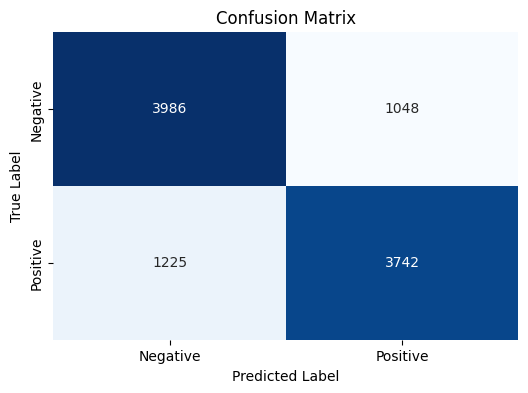

In [62]:
# confusion matrix for the best ANN model
cm = confusion_matrix(true_test_labels, predicted_test_labels)

labels = ["Negative", "Positive"]
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

print("\nConfusion Matrix:")
print(cm_df)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"], cbar = False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Below is the ROC-AUC curve for the `LSTM_classifier` model obtained after training and hyperparameter tuning.

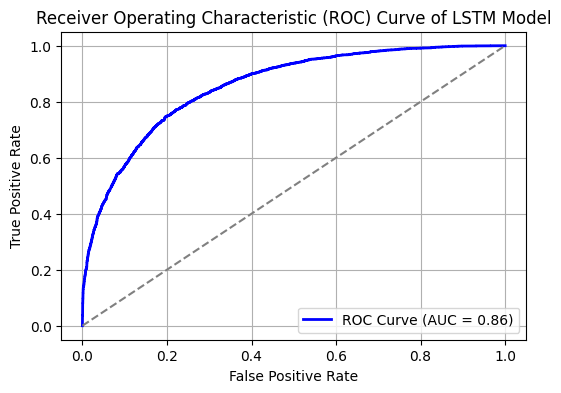

In [63]:
# Ensure model is in evaluation mode
model.eval()

# Lists to store true labels and predicted probabilities
y_true = []
y_probs = [] 

for inputs, labels in test_loader: 
    inputs = inputs.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        outputs = model(inputs)
        probs = torch.sigmoid(outputs) 

    y_true.extend(labels.cpu().numpy())
    y_probs.extend(probs.cpu().numpy())

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve of LSTM Model")
plt.legend(loc="lower right")
plt.grid()
plt.show()